In [1]:
from QiskitTranspiler.transpiler.passes.layout.layout import Layout
from qiskit import QuantumCircuit
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit_aer import AerSimulator
from QiskitTranspiler.transpiler.passes.translation.translator import translate_circuit
from qiskit.converters import circuit_to_dag, dag_to_circuit
from QiskitTranspiler.transpiler.transpile import transpile, apply_layout
from QiskitTranspiler.transpiler.passes.layout.layout import Layout
from QiskitTranspiler.transpiler.passes.translation.translator import translate_circuit
from QiskitTranspiler.transpiler.passes.optimization.optimization import optimize

In [86]:
def transpile_with_mapping(qc, backend):
    coupling_map = backend.coupling_map
    circuit = qc
    # print(coupling_map)

    INFRASTRUCTURE_GATES = { "measure", "delay", "reset"}
    CONTROL_FLOW_GATES = {"if_else", "for_loop", "switch_case", "while_loop", "break", "continue"}

    basis_gates = [
        g for g in backend.operation_names 
        if g not in INFRASTRUCTURE_GATES and g not in CONTROL_FLOW_GATES
    ]

    # print("Basis gates:", basis_gates)

    layout_no_translate, mapping = Layout.run_layout(circuit, backend)

    initial_mapping = {v: k for k, v in mapping.items()}
    layout_no_translate.draw("mpl")
    # for instruction in layout_no_translate.data:
    #     op = instruction.operation
    #     qubits = [layout_no_translate.find_bit(qubit).index for qubit in instruction.qubits]
    #     cbits = [layout_no_translate.find_bit(cbit).index for cbit in instruction.clbits]
    #     if(op.name == "swap"):
    #         initial_mapping[qubits[0]], initial_mapping[qubits[1]] = initial_mapping[qubits[1]], initial_mapping[qubits[0]]


    # layout_no_translate = translate_circuit(layout_no_translate, basis=basis_gates)

    # layout_no_translate = optimize(layout_no_translate)

    return layout_no_translate, mapping

In [112]:
def swap_back_for_statevector(qc : QuantumCircuit, mapping):
    swapped_qc = qc.copy()
    
    ok = False
    while not ok:
        ok = True
        for should_be, current in mapping.items():
            if should_be != current:
                # find which virtual qubit is currently at the position where should_be is
                other_virtual = next(k for k, v in mapping.items() if v == should_be)
                
                # swap should_be and current in the mapping
                mapping[should_be], mapping[other_virtual] = mapping[other_virtual], mapping[should_be]
                
                # apply the corresponding SWAP to the circuit
                swapped_qc.swap(should_be, current)
                
                ok = False
    print("Final mapping after swaps:", mapping)
    return swapped_qc

In [114]:
from qiskit.circuit import QuantumCircuit

def transpile_with_mapping(qc, backend):
    coupling_map = backend.coupling_map
    circuit = qc
    # print(coupling_map)

    INFRASTRUCTURE_GATES = { "measure", "delay", "reset"}
    CONTROL_FLOW_GATES = {"if_else", "for_loop", "switch_case", "while_loop", "break", "continue"}

    basis_gates = [
        g for g in backend.operation_names 
        if g not in INFRASTRUCTURE_GATES and g not in CONTROL_FLOW_GATES
    ]
    
    layout_no_translate, mapping = Layout.run_layout(qc, backend)
    
    # initial_mapping usually maps {Virtual: Physical}
    # We create a working map to track where each virtual qubit ends up
    num_qubits = layout_no_translate.num_qubits
    
    # Start with an identity mapping: {0: 0, 1: 1, 2: 2, ...}
    # Key = Virtual Qubit Index, Value = Current Physical Position
    current_mapping = {i: i for i in range(num_qubits)}
    
    data = layout_no_translate.data
    i = 0
    while i < len(data):
        inst = data[i]
        
        # 1. Detect explicit SWAP gates
        if inst.operation.name == 'swap':
            q1 = layout_no_translate.find_bit(inst.qubits[0]).index
            q2 = layout_no_translate.find_bit(inst.qubits[1]).index
            _update_position(current_mapping, q1, q2)
            i += 1
            continue

        # 2. Detect CNOT triplets: CX(a,b), CX(b,a), CX(a,b)
        if i + 2 < len(data):
            inst1, inst2, inst3 = data[i], data[i+1], data[i+2]
            
            if (inst1.operation.name == 'cx' and 
                inst2.operation.name == 'cx' and 
                inst3.operation.name == 'cx'):
                
                # Get physical indices
                q1_a = layout_no_translate.find_bit(inst1.qubits[0]).index
                q1_b = layout_no_translate.find_bit(inst1.qubits[1]).index
                
                q2_a = layout_no_translate.find_bit(inst2.qubits[0]).index
                q2_b = layout_no_translate.find_bit(inst2.qubits[1]).index
                
                q3_a = layout_no_translate.find_bit(inst3.qubits[0]).index
                q3_b = layout_no_translate.find_bit(inst3.qubits[1]).index
                
                # Pattern check: CX(a,b), CX(b,a), CX(a,b)
                if (q1_a == q2_b == q3_a) and (q1_b == q2_a == q3_b):
                    _update_position(current_mapping, q1_a, q1_b)
                    i += 3 
                    continue
        
        i += 1
    
    layout_no_translate = swap_back_for_statevector(layout_no_translate, current_mapping)
    

    layout_no_translate = translate_circuit(layout_no_translate, basis=basis_gates)

    layout_no_translate = optimize(layout_no_translate)

    return layout_no_translate, current_mapping

def _update_position(mapping_dict, phys_a, phys_b):
    """
    Swaps the virtual qubits currently residing at physical locations a and b.
    """
    # Find which virtual keys are currently mapped to these physical values
    virt_a = next(k for k, v in mapping_dict.items() if v == phys_a)
    virt_b = next(k for k, v in mapping_dict.items() if v == phys_b)
    
    # Swap their values
    mapping_dict[virt_a], mapping_dict[virt_b] = phys_b, phys_a

In [88]:
from qiskit_ibm_runtime.fake_provider import FakeFez, FakeTorino, FakeMarrakesh, FakePerth
from qiskit_ibm_runtime import SamplerV2 as Sampler

#Testing first with a simulator, then with a real backend
backend = FakeFez()



In [89]:
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator
import numpy as np

def verify_equivalence(original_qc, routed_qc, mapping):
    """
    Verify that routed_qc is functionally equivalent to original_qc
    up to the qubit permutation defined by mapping.
    mapping: dict {virtual: physical}
    """
    sim = AerSimulator(method='statevector')

    # get statevector of original (no measurements)
    orig_no_meas = original_qc.remove_final_measurements(inplace=False)
    orig_no_meas.save_statevector()
    sv_orig = Statevector(sim.run(orig_no_meas).result().get_statevector())

    # get statevector of routed (no measurements)
    routed_no_meas = QuantumCircuit(routed_qc.num_qubits, routed_qc.num_clbits)
    for instruction in routed_qc.data:
        op = instruction.operation
        qubits = [routed_qc.find_bit(qubit).index for qubit in instruction.qubits]
        cbits = [routed_qc.find_bit(cbit).index for cbit in instruction.clbits]

        if(op.name != "measure"):
            routed_no_meas.append(op, qubits, cbits)
    routed_no_meas.save_statevector()
    sv_routed = Statevector(sim.run(routed_no_meas).result().get_statevector())

    # build the permutation: where did each physical qubit end up?
    n = original_qc.num_qubits
    perm = [mapping[v] for v in range(n)]

    # apply inverse permutation to routed statevector
    # sv_routed_permuted = sv_routed.permute(perm)

    # compare up to global phase
    return sv_orig, sv_routed

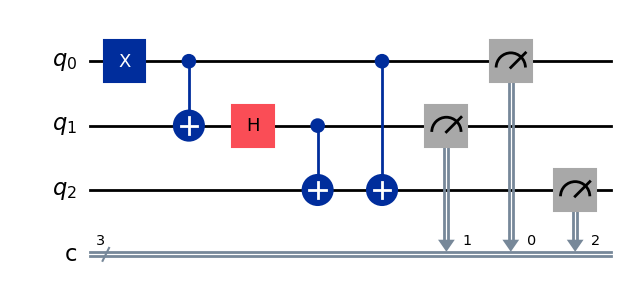

In [115]:
qc = QuantumCircuit(3, 3)
qc.x(0)
qc.cx(0, 1)
qc.h(1)
qc.cx(1, 2)
qc.cx(0, 2)
qc.measure([0, 1, 2], [0, 1, 2])
qc.draw("mpl")

Final mapping after swaps: {0: 0, 1: 1, 2: 2}
[BasisTranslator] Warning: Found a built-in equivalence table that covers the provided custom_basis. Using 'heron'


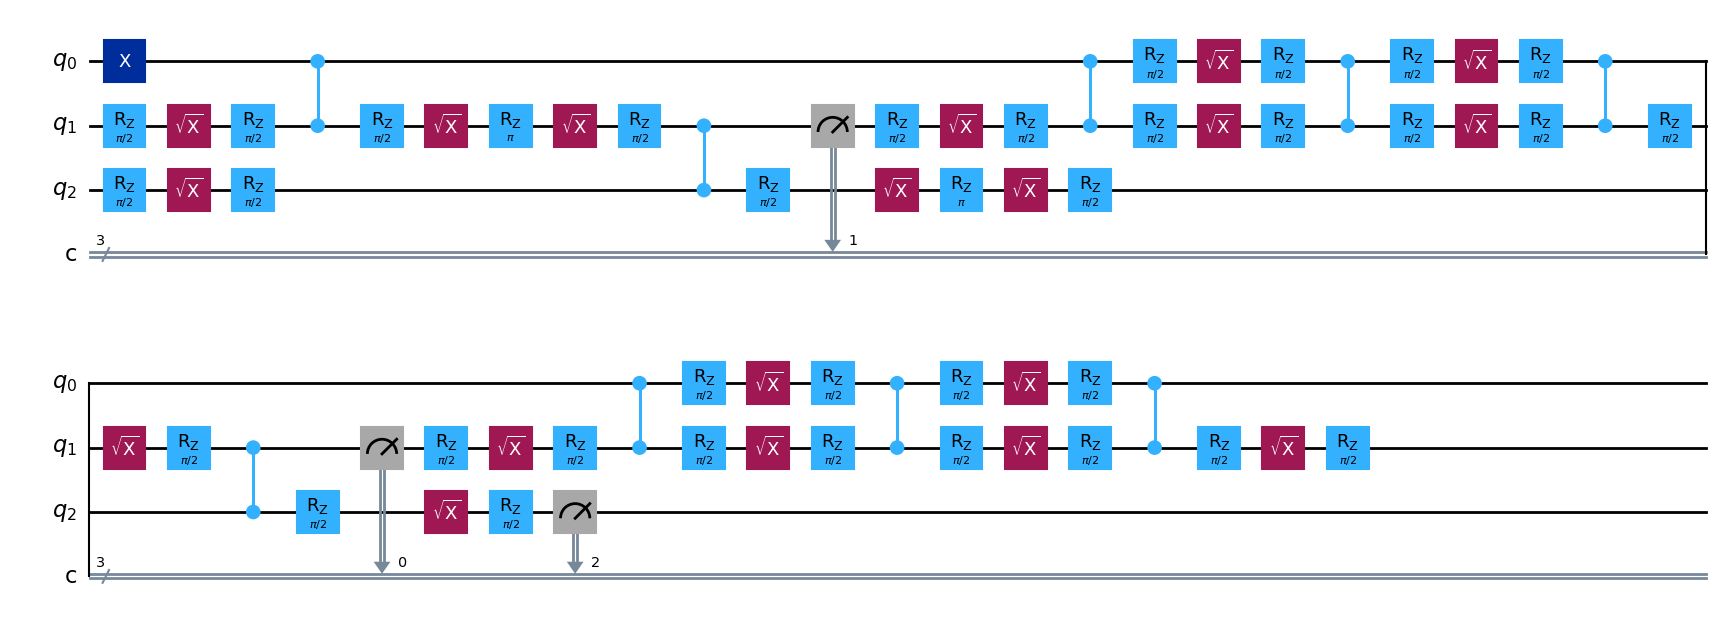

In [116]:
tqc, mapping = transpile_with_mapping(qc, backend)
tqc.draw("mpl")

In [117]:
print("Mapping:", mapping)

Mapping: {0: 0, 1: 1, 2: 2}


In [120]:
sv1, sv2 = verify_equivalence(qc, tqc, mapping)
sv1.draw("latex")

<IPython.core.display.Latex object>

In [121]:
sv2.draw("latex")

<IPython.core.display.Latex object>

In [122]:
from qiskit.quantum_info import state_fidelity
fidelity = state_fidelity(sv1, sv2)
print("State fidelity:", fidelity)

State fidelity: 1.0000000000000004


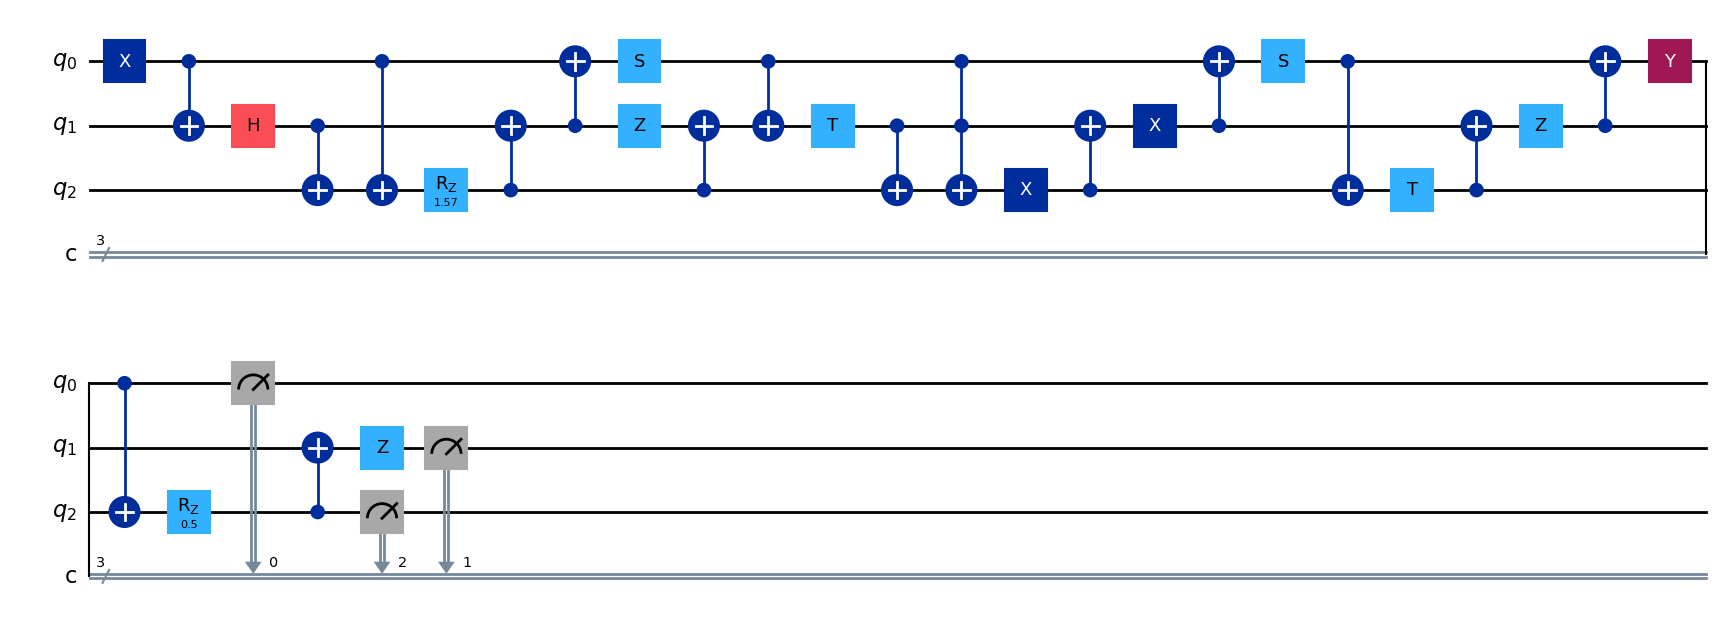

In [123]:
qc = QuantumCircuit(3, 3)

qc.x(0)
qc.cx(0, 1)
qc.h(1)
qc.cx(1, 2)
qc.cx(0, 2)
qc.rz(1.57, 2)
qc.cx(2, 1)
qc.cx(1, 0)
qc.z(1)
qc.cx(2, 1)
qc.s(0)
qc.cx(0, 1)
qc.t(1)
qc.cx(1, 2)
qc.ccx(0, 1, 2)
qc.x(2)
qc.cx(2, 1)
qc.x(1)
qc.cx(1, 0)
qc.s(0)
qc.cx(0, 2)
qc.t(2)
qc.cx(2, 1)
qc.z(1)
qc.cx(1, 0)
qc.y(0)
qc.cx(0, 2)
qc.rz(0.5, 2)
qc.cx(2, 1)
qc.z(1)

qc.measure([0, 1, 2], [0, 1, 2])
qc.draw("mpl")

Final mapping after swaps: {0: 0, 1: 1, 2: 2}
[BasisTranslator] Warning: Found a built-in equivalence table that covers the provided custom_basis. Using 'heron'


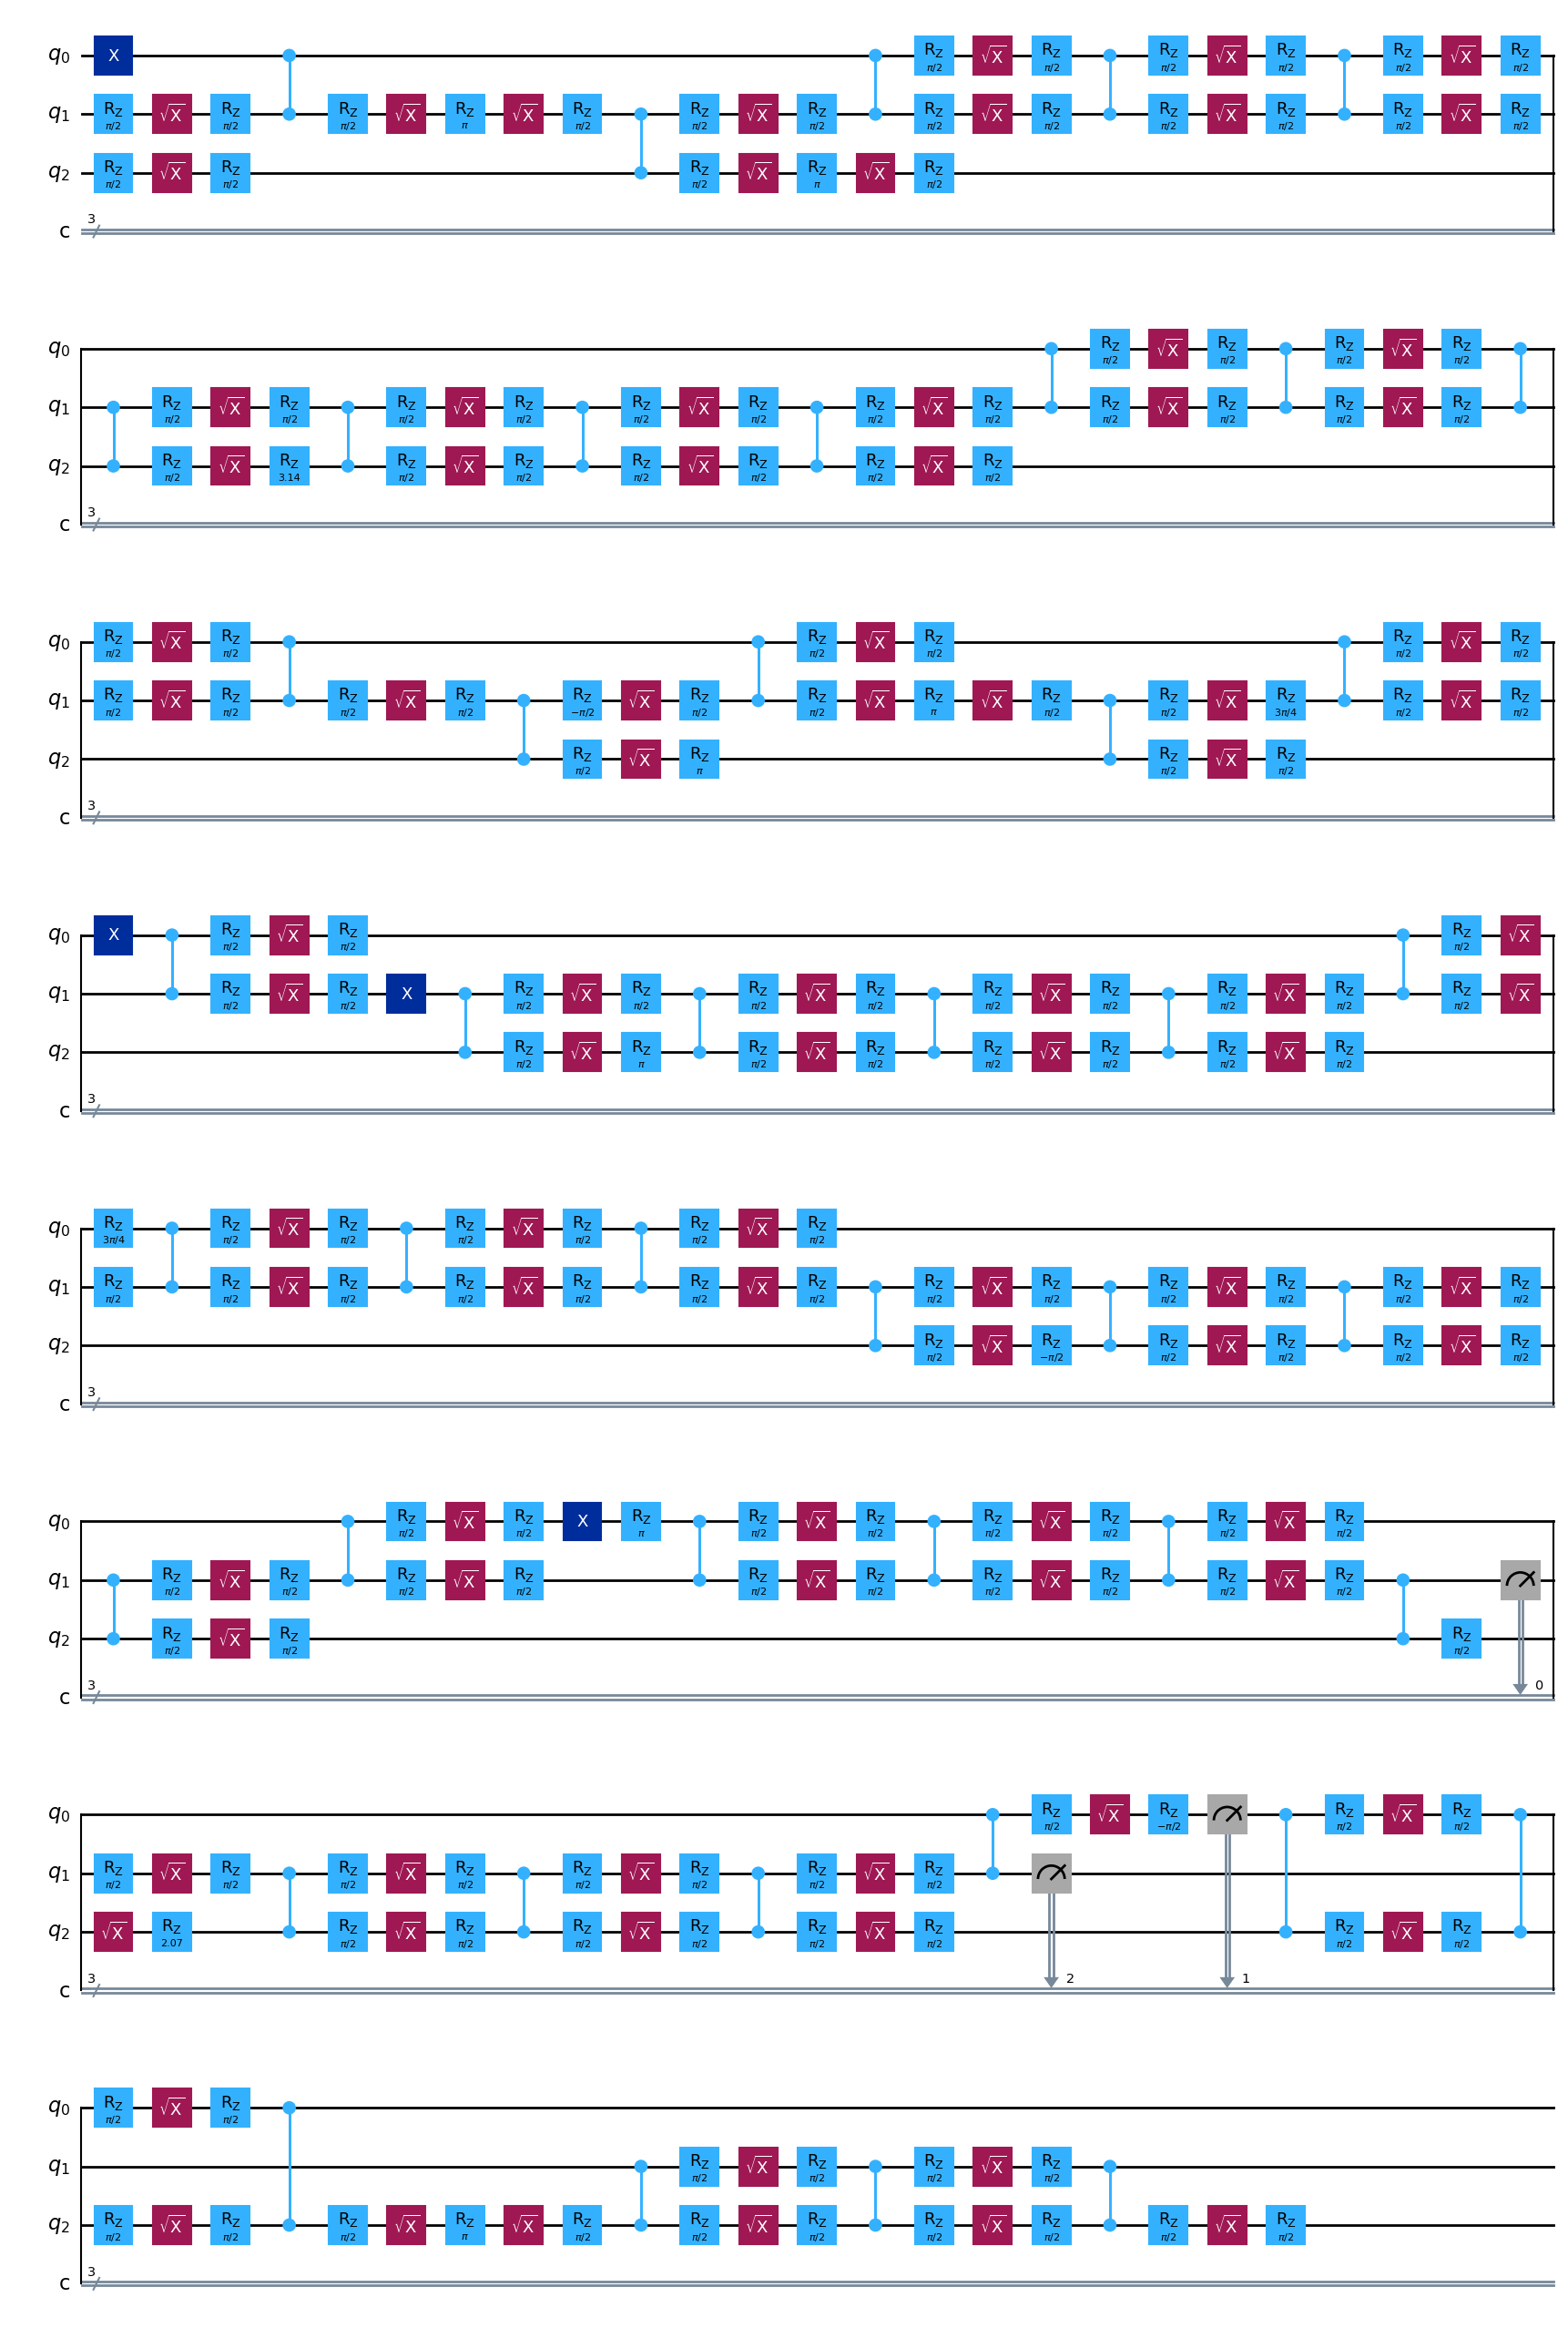

In [125]:
tqc, mapping = transpile_with_mapping(qc, backend)
tqc.draw("mpl")

In [126]:
sv1, sv2 = verify_equivalence(qc, tqc, mapping)
sv1.draw("latex")

<IPython.core.display.Latex object>

In [127]:
sv2.draw("latex")

<IPython.core.display.Latex object>

In [128]:
fidelity = state_fidelity(sv1, sv2)
print("State fidelity:", fidelity)

State fidelity: 1.000000000000015


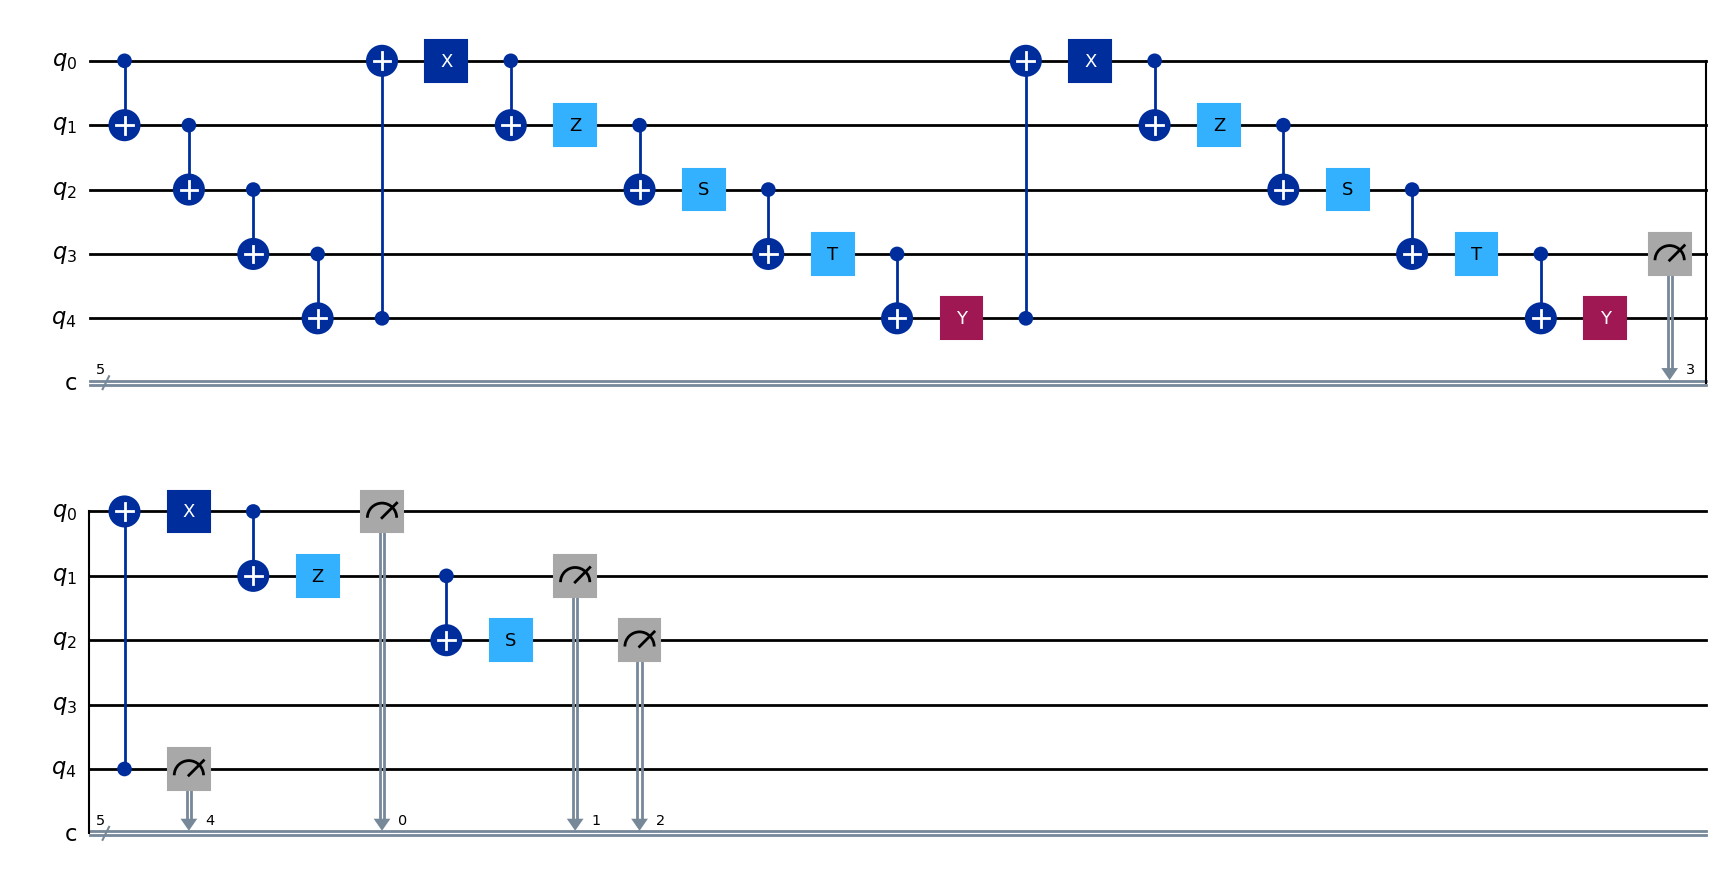

In [129]:
qc = QuantumCircuit(5, 5)
qc.cx(0, 1)
qc.cx(1, 2)
qc.cx(2, 3)
qc.cx(3, 4)
qc.cx(4, 0)
qc.x(0)
qc.cx(0, 1)
qc.z(1)
qc.cx(1, 2)
qc.s(2)
qc.cx(2, 3)
qc.t(3)
qc.cx(3, 4)
qc.y(4)
qc.cx(4, 0)
qc.x(0)
qc.cx(0, 1)
qc.z(1)
qc.cx(1, 2)
qc.s(2)
qc.cx(2, 3)
qc.t(3)
qc.cx(3, 4)
qc.y(4)
qc.cx(4, 0)
qc.x(0)
qc.cx(0, 1)
qc.z(1)
qc.cx(1, 2)
qc.s(2)
qc.measure([0, 1, 2, 3, 4], [0, 1, 2, 3, 4])
qc.draw("mpl")

In [130]:
tqc, mapping = transpile_with_mapping(qc, backend)
sv1, sv2 = verify_equivalence(qc, tqc, mapping)
sv1.draw("latex")

Final mapping after swaps: {0: 0, 1: 1, 2: 2, 3: 3, 4: 4}
[BasisTranslator] Warning: Found a built-in equivalence table that covers the provided custom_basis. Using 'heron'


<IPython.core.display.Latex object>

In [131]:
sv2.draw("latex")

<IPython.core.display.Latex object>

In [132]:
fidelity = state_fidelity(sv1, sv2)
print("State fidelity:", fidelity)

State fidelity: 1.0000000000000062
